In [101]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [102]:
# Load census tracts
tracts_2010 = gpd.read_file("C:\\UC San Diego\\GPEC447\\FinalProject\\tl_2010_42101_tract10\\tl_2010_42101_tract10.shp")
tracts_2020 = gpd.read_file("C:\\UC San Diego\\GPEC447\\FinalProject\\tl_2020_42_tract\\tl_2020_42_tract.shp")

In [103]:
# Set CRS
tracts_2010 = tracts_2010.to_crs("EPSG:2272")
tracts_2020 = tracts_2020.to_crs("EPSG:2272")

In [104]:
tracts_2010.head()

,STATEFP10,COUNTYFP10,TRACTCE10,GEOID10,NAME10,NAMELSAD10,MTFCC10,FUNCSTAT10,ALAND10,AWATER10,INTPTLAT10,INTPTLON10,geometry
0,42,101,036301,42101036301,363.01,Census Tract 363.01,G5020,S,2322732,66075,+40.0895349,-074.9667387,"POLYGON ((2748366.299 290799.127, 2748435.97 2..."
1,42,101,036400,42101036400,364,Census Tract 364,G5020,S,4501110,8014,+40.1127747,-074.9789137,"POLYGON ((2743809.154 294040.402, 2743494.584 ..."
2,42,101,036600,42101036600,366,Census Tract 366,G5020,S,1004313,1426278,+39.9470272,-075.1404472,"POLYGON ((2699720.168 236062.074, 2699719.035 ..."
3,42,101,034803,42101034803,348.03,Census Tract 348.03,G5020,S,1271533,8021,+40.0619427,-075.0023705,"POLYGON ((2735668.565 276129.136, 2735577.548 ..."
4,42,101,034702,42101034702,347.02,Census Tract 347.02,G5020,S,1016206,0,+40.0570427,-075.0283288,"POLYGON ((2730958.367 278534.172, 2730985.876 ..."


In [105]:
tracts_2010 = tracts_2010[["GEOID10", "NAME10", "geometry"]]

<Axes: >

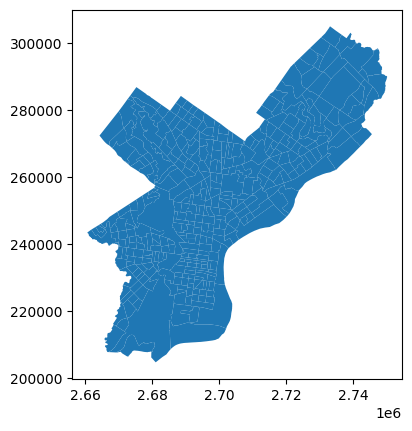

In [106]:
tracts_2010.plot()

In [107]:
tracts_2020.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,42,095,017703,42095017703,177.03,Census Tract 177.03,G5020,S,3708021,9639,+40.6498956,-075.3948647,"POLYGON ((2617473.825 488293.417, 2618424.632 ..."
1,42,101,012204,42101012204,122.04,Census Tract 122.04,G5020,S,879459,56473,+40.0009407,-075.2120769,"POLYGON ((2676981.178 254440.769, 2677375.454 ..."
2,42,129,804300,42129804300,8043,Census Tract 8043,G5020,S,1014739,0,+40.2918690,-079.5478131,"POLYGON ((1464935.135 354814.612, 1464947.835 ..."
3,42,129,804801,42129804801,8048.01,Census Tract 8048.01,G5020,S,6852606,0,+40.3011416,-079.6013733,"POLYGON ((1444658.273 360201.039, 1444672.735 ..."
4,42,129,805200,42129805200,8052,Census Tract 8052,G5020,S,1873022,0,+40.1523157,-079.8745928,"POLYGON ((1372168.652 306146.629, 1372182.815 ..."


In [108]:
tracts_2020 = tracts_2020.rename(columns={"GEOID": "GEOID20", "NAME": "NAME20"})
tracts_2020 = tracts_2020[["GEOID20", "NAME20", "geometry"]]

<Axes: >

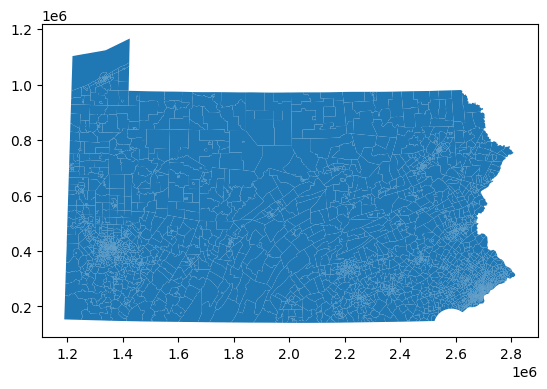

In [109]:
tracts_2020.plot()

In [110]:
# The 2020 tracts are of all of Pennsylvania while the 2010 tracts are only of Philadelphia
# Clip 2020 tracts to 2010 tracts
tracts_2020 = gpd.clip(tracts_2020, tracts_2010, keep_geom_type=True)

In [111]:
# Overlay 2010 tracts to 2020 tracts to find which 2020 tracts correspond to which 2010 tracts
overlap = gpd.overlay(
    tracts_2020,
    tracts_2010,
    how="intersection"
)

overlap["overlap_area"] = overlap.geometry.area

assignment = (
    overlap.sort_values("overlap_area", ascending=False)
    .drop_duplicates("GEOID20")
    [["GEOID20", "GEOID10", "NAME10"]]
)

c:\Users\kiana\anaconda3\envs\deepverse\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 2432 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [112]:
# Attach old 2010 tract assignment to 2020 geometries
tracts20_assigned = tracts_2020.merge(assignment, on="GEOID20", how="left")

In [113]:
# Dissolve 2020 tracts back into 2010 tract groups
tracts2020_as_2010 = tracts20_assigned.dissolve(
    by=["GEOID10", "NAME10"],
    as_index=False
)

In [114]:
tracts2020_as_2010.head()
tracts2020_as_2010.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   GEOID10   384 non-null    str     
 1   NAME10    384 non-null    str     
 2   geometry  384 non-null    geometry
 3   GEOID20   384 non-null    str     
 4   NAME20    384 non-null    str     
dtypes: geometry(1), str(4)
memory usage: 26.2 KB


<Axes: >

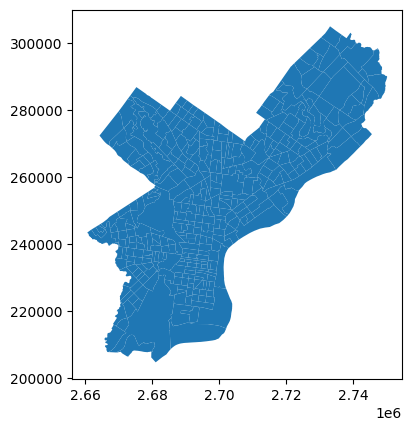

In [115]:
tracts2020_as_2010.plot()

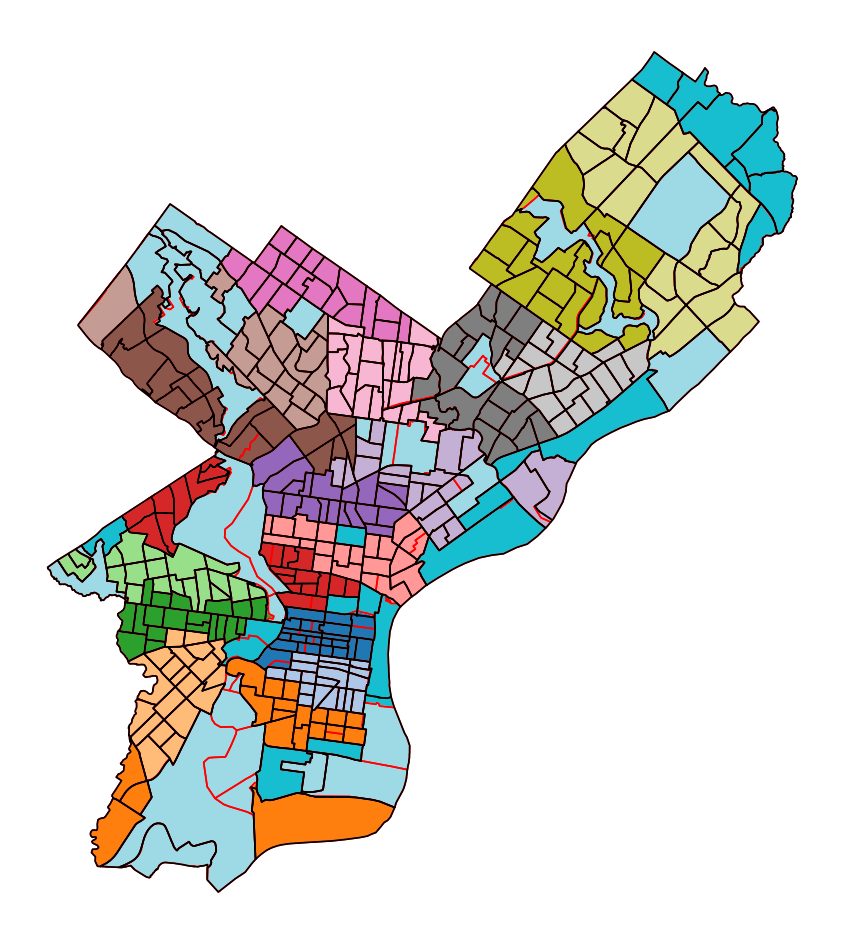

In [116]:
fig, ax = plt.subplots(figsize=(12, 12))

# Plot new census tracts
tracts2020_as_2010.plot(
    column="GEOID10",
    cmap="tab20",
    linewidth=1.2,
    edgecolor="white",
    ax=ax
)

# Overlay 2020 tract boundaries
tracts_2020.boundary.plot(
    ax=ax,
    color="red",
    linewidth=1.2
)

# Overlay 2010 tract boundaries
tracts_2010.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2
)

ax.axis("off")

plt.show()

In [118]:
# Export as a GeoJSON file
tracts2020_as_2010.to_file("C:\\UC San Diego\\GPEC447\\FinalProject\\tracts2020_as_2010.geojson", driver="GeoJSON")